### Setup

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import polars as pl
from itertools import combinations
from datetime import date
from scipy.stats import pearsonr, spearmanr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from modpa_network_utilities import (
    parse_network,
    build_graph,
    discover_runs,
    jaccard
)


In [2]:
# --- Leiden clustering ---------------------------------------------------
# LEIDEN_RESOLUTION = 0.5
LEIDEN_RESOLUTION = 2
LEIDEN_N_ITERATIONS = 2

# Seed for the partitions that are exported and used in the topology section.
LEIDEN_SEED = 42

# Leiden is stochastic, and a single seed gives no sense of how much of the
# measured (dis)agreement is seed noise. These seeds are used to report the
# median and range of the ARI and NMI. Set to (LEIDEN_SEED,) to skip.
LEIDEN_SEEDS = (42, 43, 44, 45, 46)

# --- Permutation baseline for the ARI ------------------------------------
N_PERMUTATIONS = 200
PERMUTATION_SEED = 123

# --- Topology comparison -------------------------------------------------
# Number of random non-edges drawn as the null for the indirectness and
# common-neighbour tests. This dominates the runtime of the last section.
N_TOPOLOGY_BASELINE = 100_000
TOPOLOGY_SEED = 0

MIN_SCORE = 0.6

FIG_DPI = 300

MODEL_ROOT = "../2-VAE-code/2026-09-10-HumanOnly"  # one subdirectory per model run
REFERENCE_SUBDIR = "128d-REF"  # holds exactly one run, the reference
REPLICATE_SUBDIR = "128d"  # replicate runs at a fixed dimensionality
EXCLUDED_DIMS = {}

OUTPUT_DIR = os.path.join(".", f"{date.today().isoformat()}_sensitivity_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
RUNS = discover_runs(MODEL_ROOT, REFERENCE_SUBDIR, REPLICATE_SUBDIR, excluded_dims=EXCLUDED_DIMS)
RUN_LABELS = list(RUNS.index)
REFERENCE_RUN   = RUNS.index[RUNS["is_reference"]][0]
REPLICATE_RUNS  = [label for label in RUN_LABELS if label.startswith('128_rep')]
COMPARISON_RUNS = [label for label in RUN_LABELS if not label.startswith('128_')]

print(f"{len(RUN_LABELS)} runs, reference is {REFERENCE_RUN} "
      f"(directory {RUNS.loc[REFERENCE_RUN, 'directory']})")
RUNS

14 runs, reference is 128_ref (directory 20260910-2327-s1168567929-keen_raman)


,latent_dim,replicate,is_reference,directory,path
label,,,,,
032_rep1,32,1.0,False,20260910-1839-s729727809-reverent_bouman,../2-VAE-code/2026-09-10-HumanOnly/20260910-18...
064_rep1,64,1.0,False,20260910-2155-s1733788310-friendly_engelbart,../2-VAE-code/2026-09-10-HumanOnly/20260910-21...
096_rep1,96,1.0,False,20260910-2224-s660206978-pedantic_agnesi,../2-VAE-code/2026-09-10-HumanOnly/20260910-22...
124_rep1,124,1.0,False,20260910-1910-s170997531-amazing_booth,../2-VAE-code/2026-09-10-HumanOnly/20260910-19...
128_ref,128,NaN,True,20260910-2327-s1168567929-keen_raman,../2-VAE-code/2026-09-10-HumanOnly/128d-REF/20...
128_rep1,128,1.0,False,20260910-2254-s1130818958-affectionate_ardingh...,../2-VAE-code/2026-09-10-HumanOnly/128d/202609...
128_rep2,128,2.0,False,20260910-2355-s140206771-funny_keller,../2-VAE-code/2026-09-10-HumanOnly/128d/202609...
128_rep3,128,3.0,False,20260911-0025-s1965389057-pedantic_mestorf,../2-VAE-code/2026-09-10-HumanOnly/128d/202609...
128_rep4,128,4.0,False,20260911-0059-s1223505659-keen_wilson,../2-VAE-code/2026-09-10-HumanOnly/128d/202609...


In [4]:
print('REFERENCE_RUN:', REFERENCE_RUN)
print('REPLICATE_RUNS:', REPLICATE_RUNS)
print('COMPARISON_RUNS:', COMPARISON_RUNS)

REFERENCE_RUN: 128_ref
REPLICATE_RUNS: ['128_rep1', '128_rep2', '128_rep3', '128_rep4']
COMPARISON_RUNS: ['032_rep1', '064_rep1', '096_rep1', '124_rep1', '132_rep1', '160_rep1', '192_rep1', '256_rep1', '512_rep1']


-------

### load edge lists (lazily)

In [5]:
# lazy_edgelists = {}
# for label,row in RUNS.iterrows():
#     lazy_edgelists[label] = parse_network(
#         row.path, 
#         min_score=MIN_SCORE
#     )

In [6]:
lazy_zero_filtered_edgelists = {}
for label,row in RUNS.iterrows():
    lazy_zero_filtered_edgelists[label] = parse_network(
        row.path, 
        min_score=0, 
    )

----

In [7]:
REF_filtered = parse_network(
        RUNS.loc[REFERENCE_RUN,'path'], 
        min_score=MIN_SCORE
    )
reference_edge_set = set(REF_filtered.collect()['pair_key'].to_list())
len(reference_edge_set)


14591

In [8]:
# REF_filtered.select(
#     pl.col('potential_artefact').value_counts()
# ).collect()

In [9]:
tmp = [
    lazy_zero_filtered_edgelists[_].select(
        pl.col('pair_key'),
        pl.col('Score'),
        # pl.col('distance'),
        # pl.col('qvalue'),
        pl.col('pair_key').is_in(reference_edge_set).alias('isInReference'),
        pl.lit(_).alias('model')
    ) for _ in REPLICATE_RUNS + COMPARISON_RUNS
]
tmp = pl.concat(tmp).collect()
tmp

pair_key,Score,isInReference,model
str,f64,bool,str
"""P02042|145|K|34__P24928|1857|S…",0.216848,false,"""128_rep1"""
"""O75592|178|S|21__Q9UMD9|170|S|…",0.216849,false,"""128_rep1"""
"""P46821|1443|S|21__Q9UQ35|839|S…",0.217687,false,"""128_rep1"""
"""Q63ZY6|258|T|21__Q9UK58|335|S|…",0.218489,false,"""128_rep1"""
"""Q13895|170|S|21__Q7Z4S6|1271|S…",0.218772,false,"""128_rep1"""
…,…,…,…
"""P67809|2|S|21__P67809|3|S|21""",1.0,true,"""512_rep1"""
"""Q9BTK6|143|S|21__Q9BTK6|148|S|…",1.0,true,"""512_rep1"""
"""Q9UGH3|70|S|21__Q9UGH3|71|S|21""",1.0,true,"""512_rep1"""


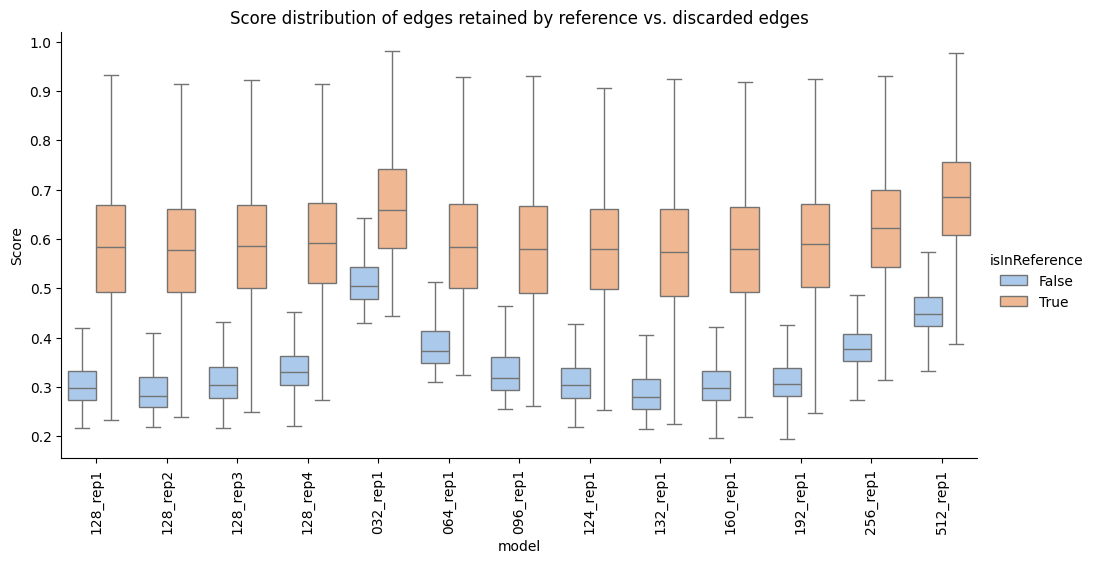

In [10]:
sns.catplot(
    data=tmp,
    kind='box',
    y='Score',
    x='model',
    hue='isInReference',
    palette='pastel',
    aspect=2,
    showfliers=False
)
plt.xticks(rotation=90)
plt.title('Score distribution of edges retained by reference vs. discarded edges')
plt.savefig(
    os.path.join(OUTPUT_DIR, 'retained-discarded-edges-scores.svg'), 
    format='svg', dpi=300, bbox_inches='tight'
    )

In [11]:
retained_edge_fraction = tmp.group_by('model','isInReference').agg(
    pl.col('Score').len().alias('count')
).pivot(
    index='model', 
    on='isInReference', 
    values='count'
).sort(
    'model'
).with_columns(
    (pl.col('true') / (pl.col('true') + pl.col('false'))).round(3).alias('fraction_retained_by_reference')
)
retained_edge_fraction.write_csv(
    os.path.join(OUTPUT_DIR, 'retained_edge_fraction.csv')
    )
retained_edge_fraction

model,false,true,fraction_retained_by_reference
str,u32,u32,f64
"""032_rep1""",846900,12412,0.014
"""064_rep1""",1828648,13697,0.007
"""096_rep1""",4415368,14108,0.003
"""124_rep1""",16373089,14540,0.001
"""128_rep1""",16161587,14524,0.001
…,…,…,…
"""132_rep1""",12685092,14472,0.001
"""160_rep1""",17680896,14554,0.001
"""192_rep1""",18502200,14558,0.001


---------

In [12]:
reference_graph = build_graph(REF_filtered.collect(engine='streaming'))

reference_degree_df = pl.DataFrame(
    list(reference_graph.degree()),
    schema=["node", "degree"],
    orient="row",
)
reference_degree_df.head()

node,degree
str,i64
"""P02686|159|R|7""",16
"""P07197|620|S|21""",2
"""P21291|192|S|21""",8
"""Q9ULV3|350|S|21""",18
"""P05387|16|S|21""",5


In [13]:
replicate_graphs = {
    label: build_graph(edges.collect(engine='streaming')) 
    for label, edges in lazy_zero_filtered_edgelists.items()
}

for label, graph in replicate_graphs.items():
    print(f"{label}: {len(graph.nodes)} nodes, {len(graph.edges)} edges")


# --- Jaccard index between node sets --------------------------------------
# At Score > 0, node sets are identical across all runs (Jaccard index is 1.0)

node_sets = {
    label: set(graph.nodes) for label, graph in replicate_graphs.items()
}

for a, b in combinations(node_sets.keys(), 2):
    jaccard_index, _ = jaccard(node_sets[a], node_sets[b])
    print(f"Jaccard index between {a} nodes and {b} nodes: {jaccard_index:.3f}")

032_rep1: 7644 nodes, 859312 edges
064_rep1: 7644 nodes, 1842345 edges
096_rep1: 7644 nodes, 4429476 edges
124_rep1: 7644 nodes, 16387629 edges
128_ref: 7644 nodes, 17102635 edges
128_rep1: 7644 nodes, 16176111 edges
128_rep2: 7644 nodes, 13197820 edges
128_rep3: 7644 nodes, 17171606 edges
128_rep4: 7644 nodes, 17633147 edges
132_rep1: 7644 nodes, 12699564 edges
160_rep1: 7644 nodes, 17695450 edges
192_rep1: 7644 nodes, 18516758 edges
256_rep1: 7644 nodes, 20284545 edges
512_rep1: 7644 nodes, 21422640 edges
Jaccard index between 032_rep1 nodes and 064_rep1 nodes: 1.000
Jaccard index between 032_rep1 nodes and 096_rep1 nodes: 1.000
Jaccard index between 032_rep1 nodes and 124_rep1 nodes: 1.000
Jaccard index between 032_rep1 nodes and 128_ref nodes: 1.000
Jaccard index between 032_rep1 nodes and 128_rep1 nodes: 1.000
Jaccard index between 032_rep1 nodes and 128_rep2 nodes: 1.000
Jaccard index between 032_rep1 nodes and 128_rep3 nodes: 1.000
Jaccard index between 032_rep1 nodes and 128_re

In [14]:
# filter the replicate graphs to only include edges with Score >= 0.6
replicate_graphs_filtered = {
    label: build_graph(edges.filter(pl.col("Score") >= 0.6).collect(engine='streaming')) 
    for label, edges in lazy_zero_filtered_edgelists.items()
}

for label, graph in replicate_graphs_filtered.items():
    print(f"{label}: {len(graph.nodes)} nodes, {len(graph.edges)} edges")


# --- Jaccard index between node sets --------------------------------------
# At higher score thresholds, node sets start to differ across runs

node_sets_filtered = {
    label: set(graph.nodes) for label, graph in replicate_graphs_filtered.items()
}

for a, b in combinations(node_sets_filtered.keys(), 2):
    jaccard_index, _ = jaccard(node_sets_filtered[a], node_sets_filtered[b])
    print(f"Jaccard index between {a} nodes and {b} nodes: {jaccard_index:.3f}")

032_rep1: 7602 nodes, 78332 edges
064_rep1: 6463 nodes, 14862 edges
096_rep1: 6446 nodes, 13929 edges
124_rep1: 6644 nodes, 15433 edges
128_ref: 6491 nodes, 14591 edges
128_rep1: 6462 nodes, 15337 edges
128_rep2: 6477 nodes, 13726 edges
128_rep3: 6846 nodes, 18065 edges
128_rep4: 6995 nodes, 20983 edges
132_rep1: 6274 nodes, 12780 edges
160_rep1: 6558 nodes, 14948 edges
192_rep1: 6755 nodes, 17344 edges
256_rep1: 7516 nodes, 46814 edges
512_rep1: 7643 nodes, 398405 edges
Jaccard index between 032_rep1 nodes and 064_rep1 nodes: 0.846
Jaccard index between 032_rep1 nodes and 096_rep1 nodes: 0.845
Jaccard index between 032_rep1 nodes and 124_rep1 nodes: 0.869
Jaccard index between 032_rep1 nodes and 128_ref nodes: 0.849
Jaccard index between 032_rep1 nodes and 128_rep1 nodes: 0.846
Jaccard index between 032_rep1 nodes and 128_rep2 nodes: 0.848
Jaccard index between 032_rep1 nodes and 128_rep3 nodes: 0.895
Jaccard index between 032_rep1 nodes and 128_rep4 nodes: 0.914
Jaccard index between

In [15]:
replicate_degree_df = [
    pl.DataFrame(
        list(replicate_graphs_filtered[_].degree()),
        schema=["node", "degree"],
        orient="row",
    ).with_columns(
        pl.col("node").is_in(set(reference_graph.nodes)).alias("isInReference"),
        pl.lit(_).alias("model")
    ) for _ in REPLICATE_RUNS + COMPARISON_RUNS
]
replicate_degree_df = pl.concat(replicate_degree_df)
replicate_degree_df

node,degree,isInReference,model
str,i64,bool,str
"""O14936|600|S|21""",5,true,"""128_rep1"""
"""Q9NV56|194|S|21""",2,false,"""128_rep1"""
"""O60825|468|T|21""",13,true,"""128_rep1"""
"""Q9NPF5|445|T|21""",10,true,"""128_rep1"""
"""O60292|401|S|21""",1,false,"""128_rep1"""
…,…,…,…
"""Q8N257|44|K|34""",10,true,"""512_rep1"""
"""P49411|259|K|34""",6,true,"""512_rep1"""
"""P31943|233|R|34""",3,true,"""512_rep1"""


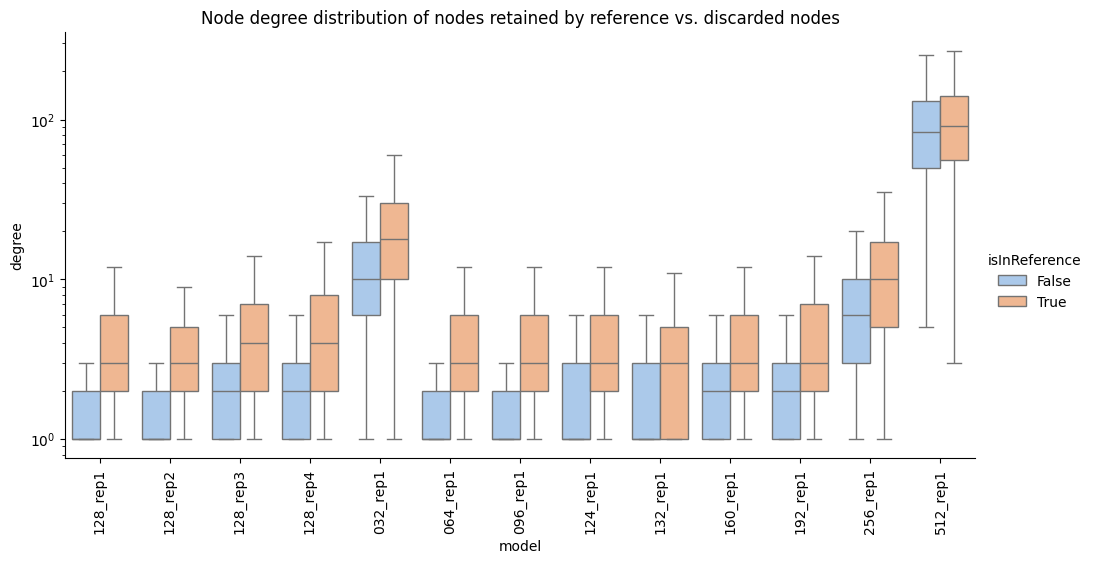

In [16]:
sns.catplot(
    data=replicate_degree_df,
    kind='box',
    x='model',
    y='degree',
    hue='isInReference',
    palette='pastel',
    showfliers=False,
    aspect=2
)
plt.xticks(rotation=90)
plt.title('Node degree distribution of nodes retained by reference vs. discarded nodes')
plt.yscale('log')
plt.savefig(
    os.path.join(OUTPUT_DIR, 'retained-discarded-nodes-degree.svg'),
    format='svg', dpi=300, bbox_inches='tight'
    )

In [17]:
replicate_degree_df.group_by('model','isInReference').agg(
    pl.col('degree').len().alias('count')
)

model,isInReference,count
str,bool,u32
"""128_rep3""",true,6105
"""096_rep1""",false,571
"""132_rep1""",true,5783
"""512_rep1""",true,6490
"""032_rep1""",false,1130
…,…,…
"""132_rep1""",false,491
"""096_rep1""",true,5875
"""128_rep2""",false,558


In [18]:
retained_node_fraction = replicate_degree_df.group_by('model','isInReference').agg(
    pl.col('degree').len().alias('count')
).pivot(
    index='model', 
    on='isInReference', 
    values='count'
).sort(
    'model'
).with_columns(
    (pl.col('true') / (pl.col('true') + pl.col('false'))).round(3).alias('fraction_retained_by_reference')
)
retained_node_fraction.write_csv(
    os.path.join(OUTPUT_DIR, 'retained_node_fraction.csv')
    )
retained_node_fraction

model,false,true,fraction_retained_by_reference
str,u32,u32,f64
"""032_rep1""",1130,6472,0.851
"""064_rep1""",587,5876,0.909
"""096_rep1""",571,5875,0.911
"""124_rep1""",647,5997,0.903
"""128_rep1""",565,5897,0.913
…,…,…,…
"""132_rep1""",491,5783,0.922
"""160_rep1""",613,5945,0.907
"""192_rep1""",680,6075,0.899


----------

#### Topology of the differing edges

The measures below characterise the edges present in the reference network but
absent from a comparison network, always evaluated inside the network that lacks
them, and always against a null of random non-adjacent node pairs:

* `indirectness_report` gives the shortest-path distance between the endpoints of a
  differing edge. It covers triangle closure (distance 2) and square closure
  (distance 3) in one measure, so it reaches up to path length 3.
* `common_neighbor_enrichment` counts the shared neighbours of the endpoints, which
  is the number of triangles the edge would close. `prob_superiority` is the
  probability that a differing edge has more common neighbours than a random
  non-edge, with 0.5 meaning no effect.
* `partition_stability` restricts both networks to their shared nodes, runs Leiden
  on each, and compares the two partitions. This is **not** the same measurement as
  the ARI reported earlier, which clusters each full network and then aligns labels
  on the shared nodes. The columns are suffixed `_common_subgraph` to keep the two
  apart.

Only the `G2_minus_G1` direction is computed, because the reverse direction is not
reported. This halves the runtime of this section.

In [19]:
def topology_summary(
    G_cmp,
    G_ref,
    *,
    label=None,
    direction="G2_minus_G1",
    weight_attr="Score",
    n_baseline=N_TOPOLOGY_BASELINE,
    baseline_seed=TOPOLOGY_SEED,
    leiden_seed=LEIDEN_SEED,
    resolution=LEIDEN_RESOLUTION,
    n_iterations=LEIDEN_N_ITERATIONS,
    output_dir=None,
    fig_dpi=FIG_DPI,
    plot=False,
):
    """Compare two graphs using the topology metrics used in this notebook.

    Parameters
    ----------
    G_cmp, G_ref : networkx.Graph
        The comparison graph and the reference graph.
    label : str | None
        Optional run label used when saving a CN comparison plot.
    direction : str
        Direction of the differing-edge comparison. Usually "G2_minus_G1".
    weight_attr : str
        Edge weight attribute used by threshold_proximity and partition_stability.
    n_baseline : int
        Number of random non-edges used for the indirectness and CN baselines.
    baseline_seed : int
        Random seed used for the non-edge baseline sampling.
    leiden_seed : int
        Random seed used by the Leiden clustering step.
    resolution : float
        Leiden resolution for partition_stability.
    n_iterations : int
        Number of Leiden iterations.
    output_dir : str | None
        Directory for saved plots.
    fig_dpi : int
        PNG DPI for the optional common-neighbour comparison figure.
    plot : bool
        If True, save a CN comparison figure when `label` and `output_dir` are set.

    Returns
    -------
    dict
        A single-row summary of all topology metrics, matching the columns used in
        the notebook's `topology` DataFrame.
    """
    from topology_compare import (
        compare_sets,
        threshold_proximity,
        indirectness_report,
        common_neighbor_enrichment,
        partition_stability,
        plot_cn_comparison,
    )

    comparison = compare_sets(G_cmp, G_ref)

    weights = threshold_proximity(
        G_cmp,
        G_ref,
        weight_attr=weight_attr,
        comparison=comparison,
    )
    indirectness = indirectness_report(
        G_cmp,
        G_ref,
        n_baseline=n_baseline,
        seed=baseline_seed,
        comparison=comparison,
        directions=(direction,),
    )[direction]
    neighbours = common_neighbor_enrichment(
        G_cmp,
        G_ref,
        n_baseline=n_baseline,
        seed=baseline_seed,
        comparison=comparison,
        directions=(direction,),
    )[direction]
    partition = partition_stability(
        G_cmp,
        G_ref,
        resolution=resolution,
        seed=leiden_seed,
        n_iterations=n_iterations,
        weight_attr=weight_attr,
    )

    differing = indirectness["differing_edges"]
    random_pairs = indirectness["random_nonedges"]
    row = {
        "run": label,
        "node_jaccard": comparison["node_jaccard"],
        "edge_jaccard": comparison["edge_jaccard"],
        **weights,
        "n_differing_edges": differing["n"],
        "n_differing_edges_skipped": differing["n_skipped"],
        "differing_frac_triangle_d2": differing["frac_triangle_d2"],
        "differing_frac_square_d3": differing["frac_square_d3"],
        "differing_frac_unreachable": differing["frac_unreachable_or_far"],
        "random_frac_triangle_d2": random_pairs["frac_triangle_d2"],
        "random_frac_square_d3": random_pairs["frac_square_d3"],
        "random_frac_unreachable": random_pairs["frac_unreachable_or_far"],
        "prop_CN_ge1_differing": neighbours["prop_CN_ge1_differing"],
        "prop_CN_ge1_random": neighbours["prop_CN_ge1_random"],
        "prob_superiority": neighbours["prob_superiority"],
        "p_greater": neighbours["p_greater"],
        "ARI_common_subgraph": partition["ARI"],
        "NMI_common_subgraph": partition["NMI"],
        "AMI_common_subgraph": partition["AMI"],
    }

    if plot and label is not None and output_dir is not None:
        fig = plot_cn_comparison(neighbours["CN_differing"], neighbours["CN_random"])
        fig.suptitle(
            f"{label} vs {REFERENCE_RUN}\n"
            f"Common neighbours of edges unique to {REFERENCE_RUN} versus random non-edges",
            y=0.98,
        )
        fig.tight_layout(rect=(0, 0, 1, 0.88))
        fig.savefig(
            os.path.join(output_dir, f"common_neighbour_enrichment_{label}_vs_{REFERENCE_RUN}.png"),
            dpi=fig_dpi,
            bbox_inches="tight",
        )
        plt.close(fig)

    return row


# Example usage:
# topology_rows = []
# for label in COMPARISON_RUNS:
#     topology_rows.append(
#         topology_summary(
#             graphs[label],
#             graphs[REFERENCE_RUN],
#             label=label,
#             direction="G2_minus_G1",
#             output_dir=OUTPUT_DIR,
#             plot=True,
#         )
#     )
#
# topology = pl.DataFrame(topology_rows)
# topology.write_csv(os.path.join(OUTPUT_DIR, "topology_comparison.csv"))
# topology.to_pandas().set_index("run").round(3)


In [20]:
topology_rows = []
for label in REPLICATE_RUNS+COMPARISON_RUNS:
    topology_rows.append(
        topology_summary(
            replicate_graphs_filtered[label],
            reference_graph,
            # graphs[REFERENCE_RUN],
            label=label,
            direction="G2_minus_G1",
            output_dir=OUTPUT_DIR,
            plot=True,
        )
    )
topology = pl.DataFrame(topology_rows).sort("run")
topology.write_csv(os.path.join(OUTPUT_DIR, "topology_comparison.csv"))
topology

run,node_jaccard,edge_jaccard,G1_shared_median,G1_only_median,G2_shared_median,G2_only_median,n_differing_edges,n_differing_edges_skipped,differing_frac_triangle_d2,differing_frac_square_d3,differing_frac_unreachable,random_frac_triangle_d2,random_frac_square_d3,random_frac_unreachable,prop_CN_ge1_differing,prop_CN_ge1_random,prob_superiority,p_greater,ARI_common_subgraph,NMI_common_subgraph,AMI_common_subgraph
str,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""032_rep1""",0.849232,0.102106,0.705384,0.631075,0.655923,0.620752,5958,24,0.655589,0.256294,0.088117,0.03592,0.20648,0.7576,0.655589,0.03592,0.815274,0.0,0.185801,0.45507,0.368011
"""064_rep1""",0.830178,0.265598,0.68223,0.623964,0.677398,0.622131,7328,1082,0.389192,0.218204,0.392604,0.00364,0.01182,0.98454,0.389192,0.00364,0.692997,0.0,0.281675,0.682175,0.513879
"""096_rep1""",0.831917,0.275834,0.679563,0.623012,0.677121,0.622067,7278,1147,0.380187,0.185765,0.434048,0.0025,0.00877,0.98873,0.380187,0.0025,0.688984,0.0,0.273705,0.686637,0.522304
"""124_rep1""",0.840151,0.264967,0.676037,0.62157,0.676153,0.621969,7475,827,0.374314,0.227291,0.398395,0.00324,0.01233,0.98443,0.374314,0.00324,0.685718,0.0,0.305813,0.670435,0.517528
"""128_rep1""",0.835743,0.274562,0.68135,0.623125,0.674769,0.621815,7079,1065,0.367001,0.217545,0.415454,0.0037,0.01154,0.98476,0.367001,0.0037,0.681796,0.0,0.282037,0.676371,0.515231
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""132_rep1""",0.828273,0.281234,0.677128,0.622293,0.678789,0.622162,7337,1246,0.338694,0.212212,0.449094,0.00259,0.00829,0.98912,0.338694,0.00259,0.668138,0.0,0.298934,0.709085,0.536987
"""160_rep1""",0.836852,0.271534,0.677908,0.621549,0.675452,0.622097,7383,900,0.35812,0.223486,0.418394,0.00305,0.01057,0.98638,0.35812,0.00305,0.677685,0.0,0.283298,0.663819,0.508935
"""192_rep1""",0.847162,0.267513,0.678369,0.621868,0.672587,0.621589,7110,741,0.372152,0.214205,0.413643,0.00372,0.01305,0.98323,0.372152,0.00372,0.684431,0.0,0.279714,0.647445,0.506156


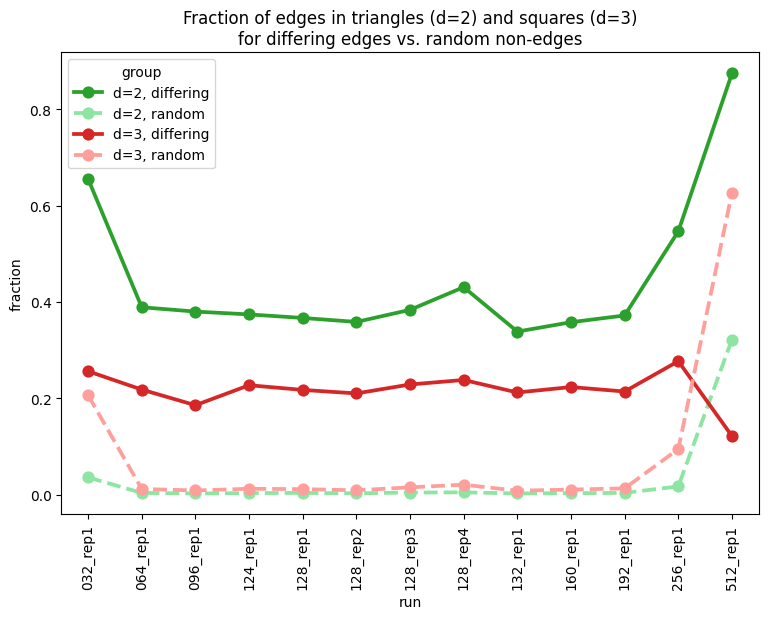

In [21]:
plt.figure(figsize=(9, 6))
sns.pointplot(
    data=topology,
    x='run',
    y='differing_frac_triangle_d2',
    color=sns.color_palette()[2],
    label='d=2, differing'
)
sns.pointplot(
    data=topology,
    x='run',
    y='random_frac_triangle_d2',
    color=sns.color_palette('pastel')[2],
    ls='--',
    label='d=2, random'
)
sns.pointplot(
    data=topology,
    x='run',
    y='differing_frac_square_d3',
    color=sns.color_palette()[3],
    label='d=3, differing'
)
sns.pointplot(
    data=topology,
    x='run',
    y='random_frac_square_d3',
    color=sns.color_palette('pastel')[3],
    ls='--',
    label='d=3, random'
)
plt.xticks(rotation=90)
plt.legend(title='group')
plt.ylabel('fraction')
plt.title('Fraction of edges in triangles (d=2) and squares (d=3)\nfor differing edges vs. random non-edges')
plt.savefig(
    os.path.join(OUTPUT_DIR, 'differing_vs_random_triangle_fraction.svg'),
    format='svg', dpi=300, bbox_inches='tight'
)
plt.show()

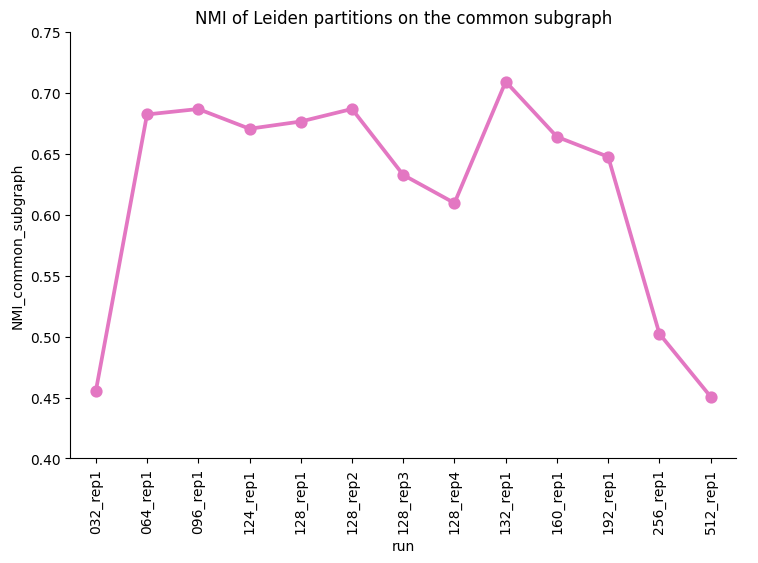

In [ ]:
sns.catplot(
    data=topology,
    kind='point',
    x='run',
    y='NMI_common_subgraph',
    aspect=1.5,
    color=sns.color_palette()[6]
)
plt.xticks(rotation=90) 
plt.ylim(0.4, 0.75)
plt.ylabel('NMI')
plt.title('NMI of Leiden partitions on the common subgraph')
plt.savefig(
    os.path.join(OUTPUT_DIR, 'NMI_common_subgraph_across_runs.svg'),
    format='svg', dpi=300, bbox_inches='tight'
)
plt.show()

-----------

#### Edge weight and node degree correlation on shared edges/nodes 

In [23]:
def edge_weight_correlation(G1, G2, weight_attr="Score"):
    """Return the shared-edge weight dataframe and associated stats."""
    shared_edges = set(map(frozenset, G1.edges())) & set(map(frozenset, G2.edges()))
    rows = []
    for edge in sorted(shared_edges, key=lambda e: tuple(sorted(e))):
        u, v = tuple(edge)
        if not G1.has_edge(u, v) or not G2.has_edge(u, v):
            continue
        a = G1[u][v].get(weight_attr)
        b = G2[u][v].get(weight_attr)
        if a is None or b is None:
            continue
        rows.append({f"{weight_attr}_G1": float(a), f"{weight_attr}_G2": float(b)})

    df = pd.DataFrame(rows)
    if df.empty:
        return {"df": df, "correlation": float("nan"), "pvalue": float("nan"), "n_shared": 0}

    corr, pvalue = pearsonr(df[f"{weight_attr}_G1"], df[f"{weight_attr}_G2"])
    return {"df": df, "correlation": corr, "pvalue": pvalue, "n_shared": len(df)}


def node_degree_correlation(G1, G2):
    """Return the shared-node degree dataframe and associated stats."""
    shared_nodes = sorted(set(G1.nodes) & set(G2.nodes))
    rows = [
        {
            "node": node,
            "degree_G1": G1.degree(node),
            "degree_G2": G2.degree(node),
        }
        for node in shared_nodes
    ]
    df = pd.DataFrame(rows)
    if df.empty:
        return {"df": df, "correlation": float("nan"), "pvalue": float("nan"), "n_shared": 0}

    corr, pvalue = spearmanr(df["degree_G1"], df["degree_G2"])
    return {"df": df, "correlation": corr, "pvalue": pvalue, "n_shared": len(df)}


# def degree_correlation_(G1, G2):
#     """Backward-compatible wrapper returning the Spearman rho only."""
#     result = node_degree_correlation(G1, G2)
#     return result["correlation"]


# def plot_edge_weight_correlation(G1, G2, weight_attr="Score"):
#     """Alias returning the dataframe and summary stats for custom plotting."""
#     return edge_weight_correlation(G1, G2, weight_attr=weight_attr)


# def plot_node_degree_correlation(G1, G2):
#     """Alias returning the dataframe and summary stats for custom plotting."""
#     return node_degree_correlation(G1, G2)


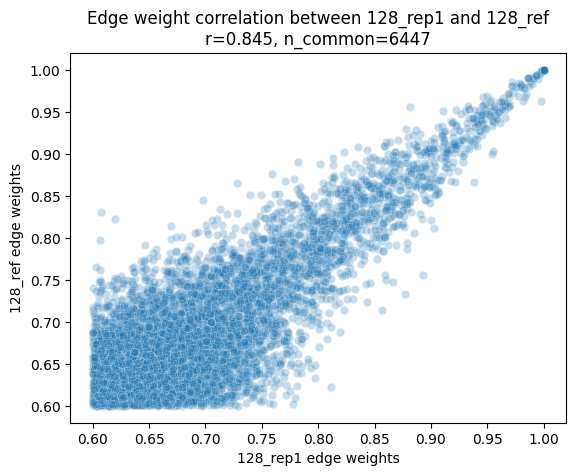

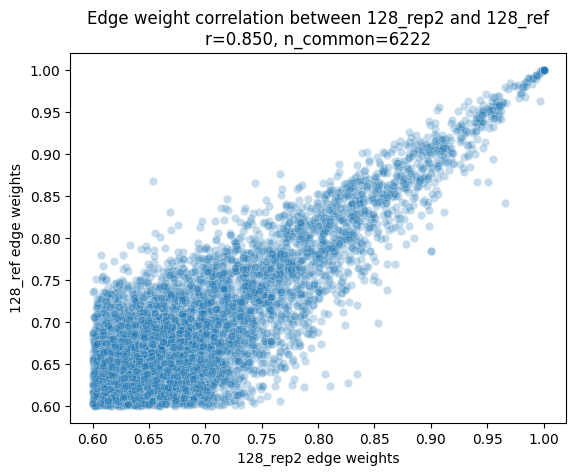

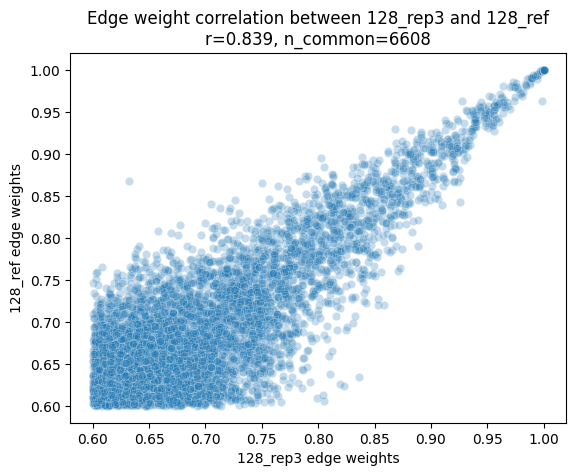

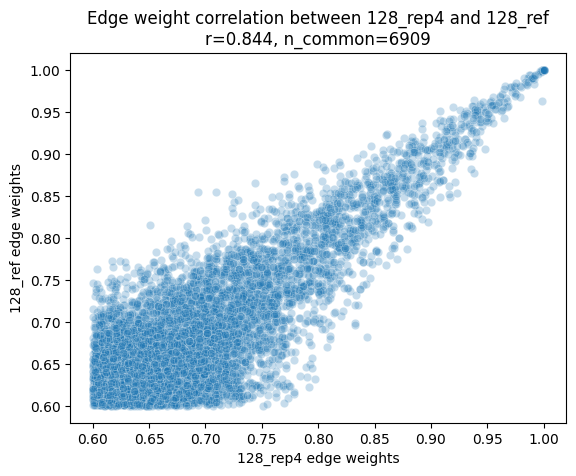

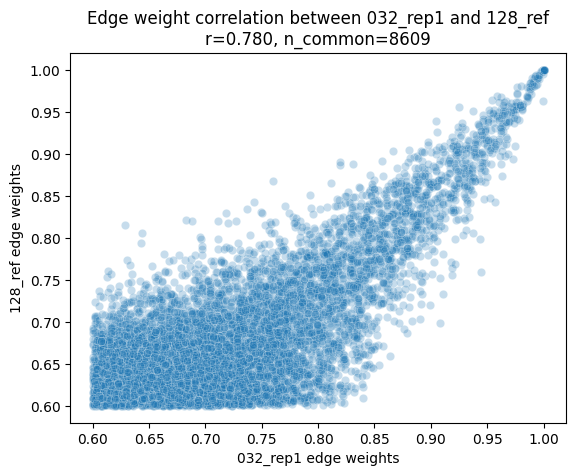

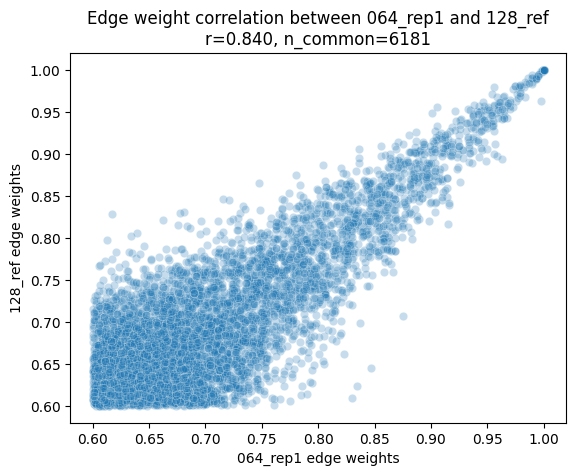

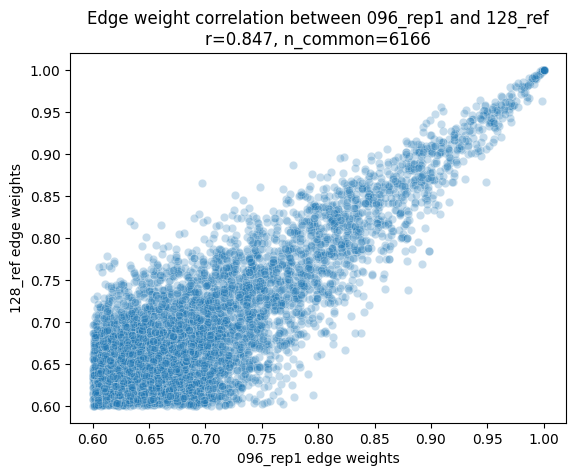

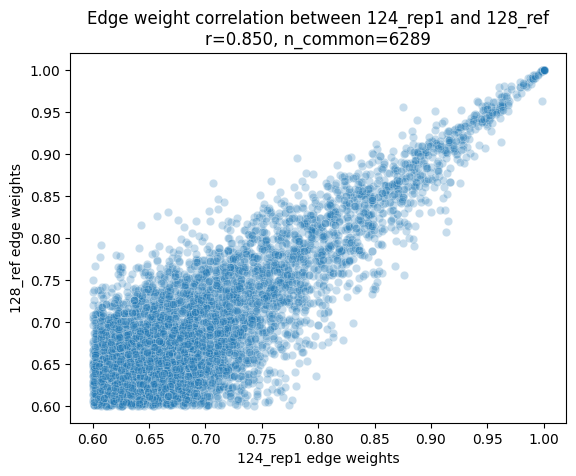

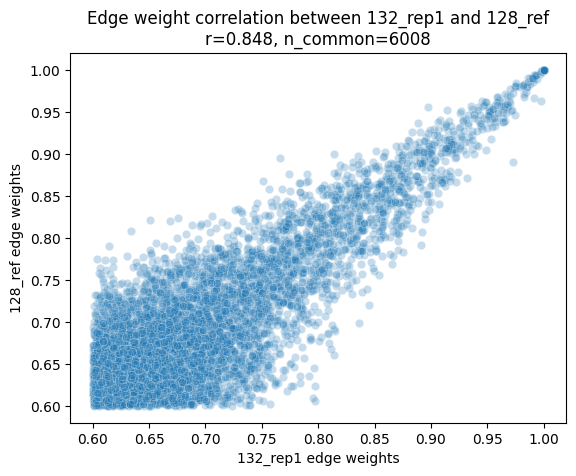

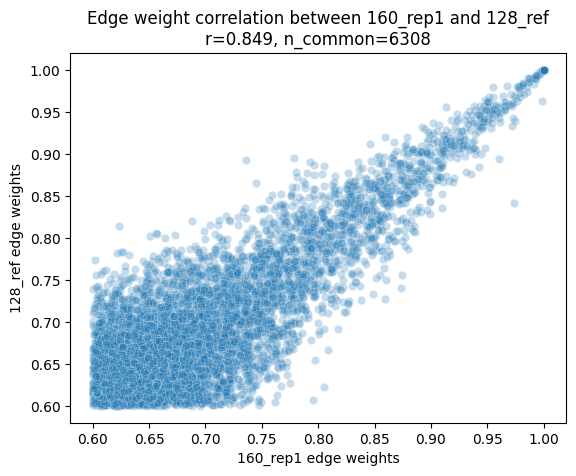

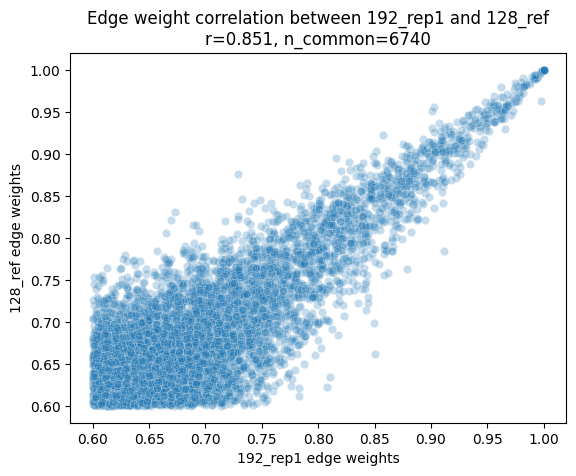

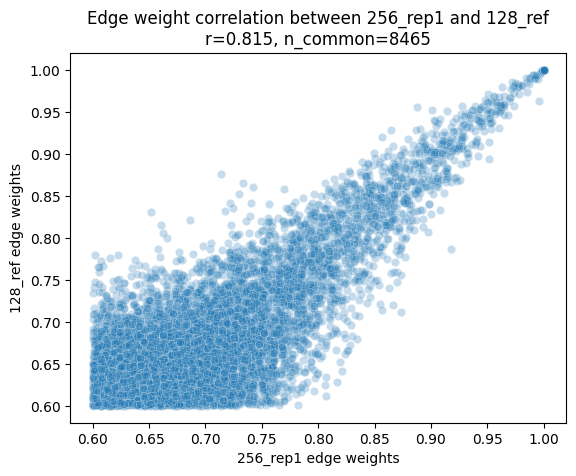

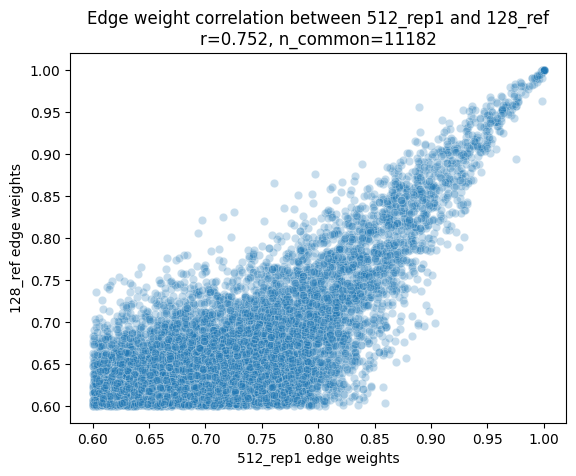

In [24]:
edge_weight_correlation_results = []
for label in REPLICATE_RUNS+COMPARISON_RUNS:
    results = edge_weight_correlation(
        replicate_graphs_filtered[label], 
        reference_graph)
    edge_weight_correlation_results.append(
        {
            "run": label,
            "edge_weight_pearsonr": results['correlation'],
            "pearsonr_pvalue": results['pvalue'],
            "n_shared_edges": results['n_shared'],
        }
    )

    sns.scatterplot(
        data=results['df'],
        x='Score_G1',
        y='Score_G2',
        alpha=0.25,
    )
    plt.title(
        f"Edge weight correlation between {label} and {REFERENCE_RUN}\n"+
        f"r={results['correlation']:.3f}, n_common={results['n_shared']}"
    )
    plt.xlabel(f"{label} edge weights")
    plt.ylabel(f"{REFERENCE_RUN} edge weights")
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"edge_weight_correlation_{label}_vs_{REFERENCE_RUN}.png"),
        dpi=FIG_DPI,
        bbox_inches="tight"
    )
    plt.show()


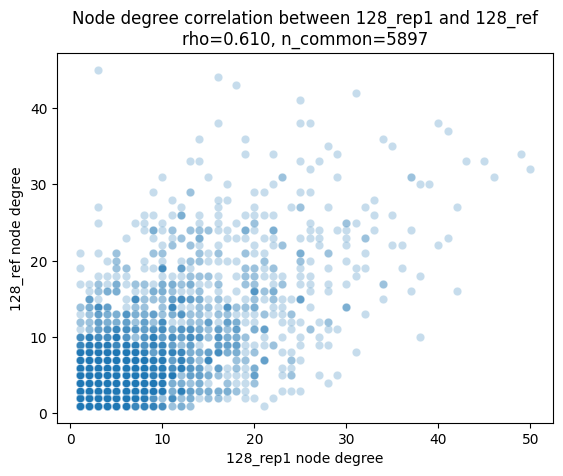

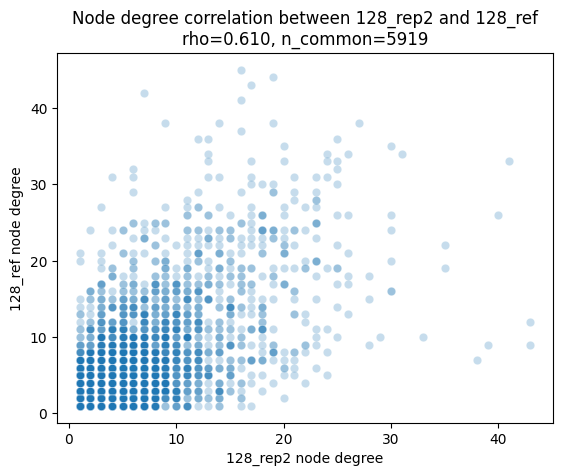

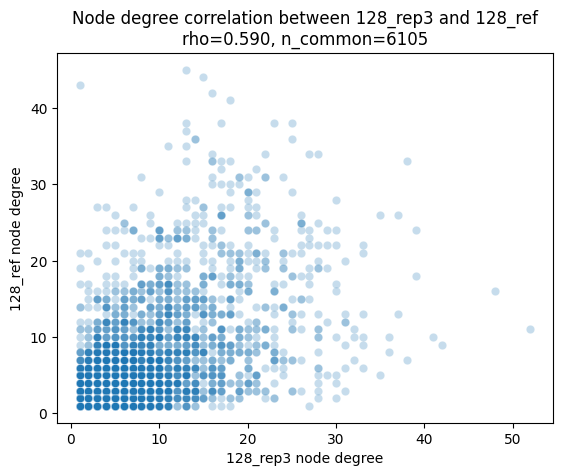

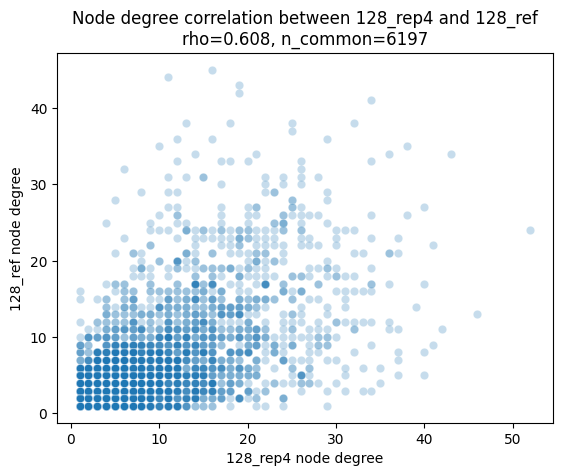

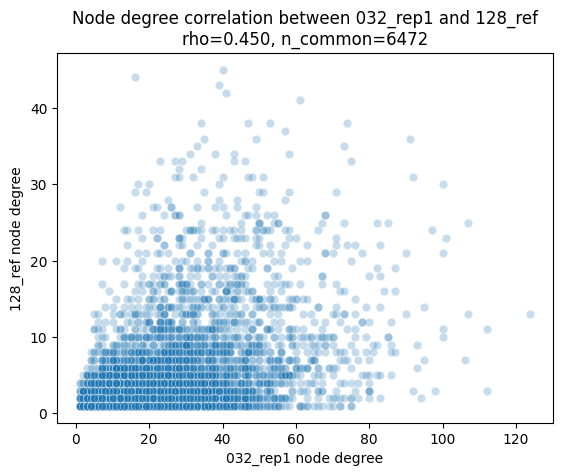

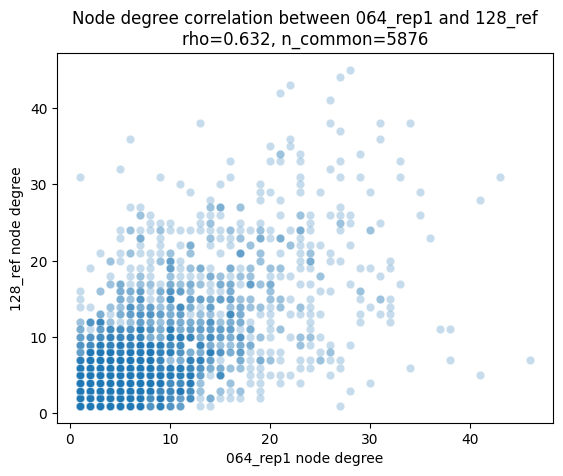

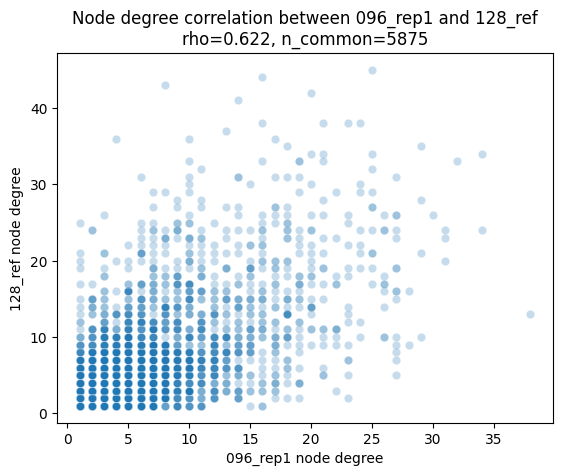

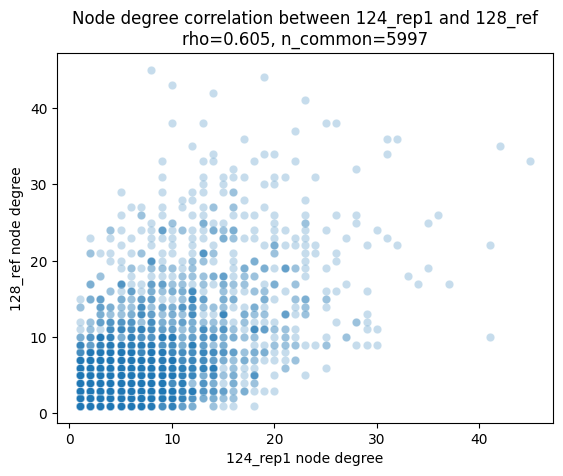

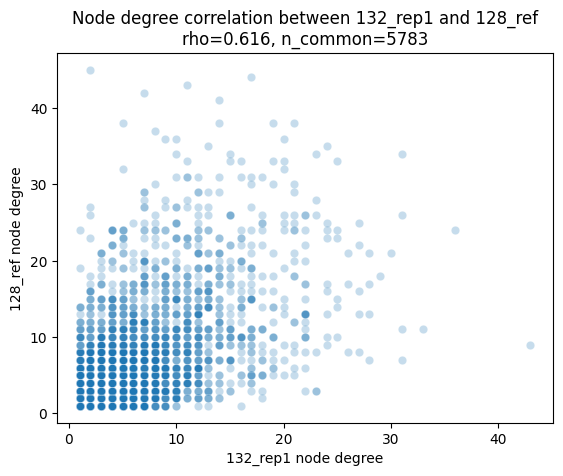

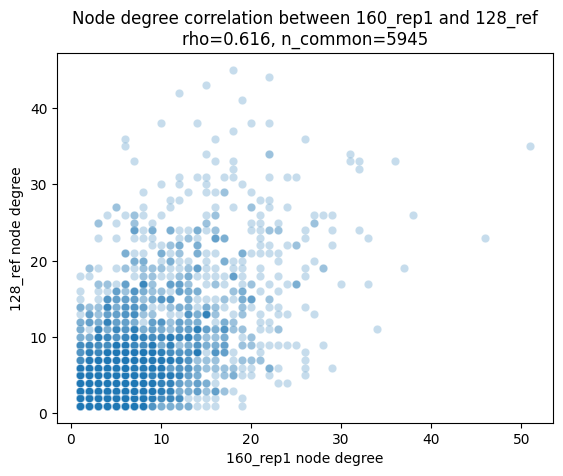

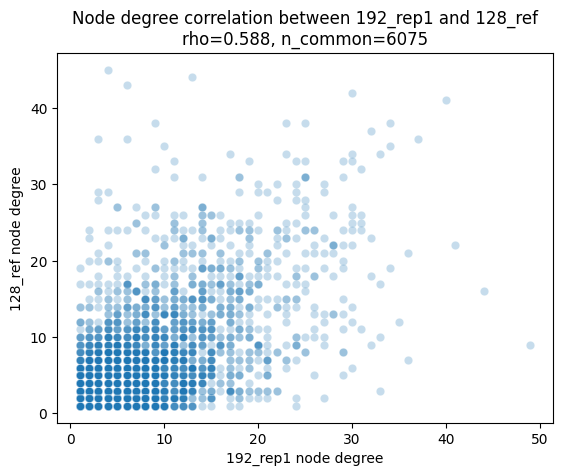

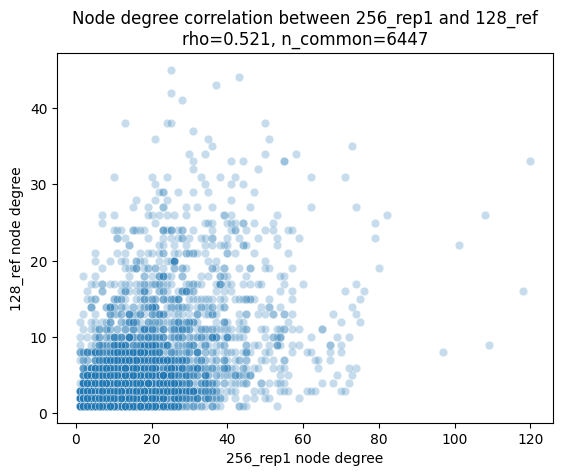

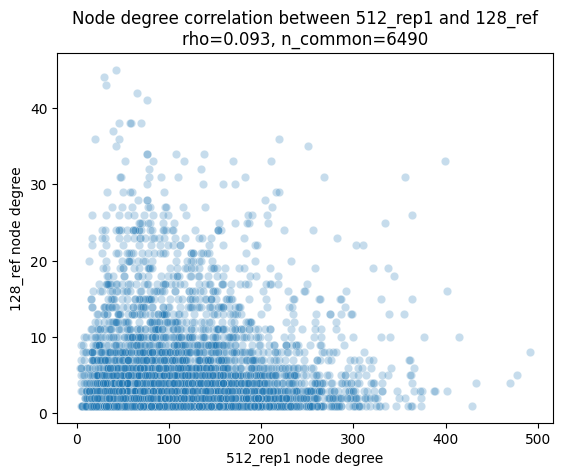

In [25]:
node_degree_correlation_results = []
for label in REPLICATE_RUNS+COMPARISON_RUNS:
    result = node_degree_correlation(
        replicate_graphs_filtered[label],
        reference_graph,
    )
    node_degree_correlation_results.append(
        {
            "run": label,
            "node_degree_spearmanr": result["correlation"],
            "spearmanr_pvalue": result["pvalue"],
            "n_shared_nodes": result["n_shared"],
        }
    )

    sns.scatterplot(
        data=result["df"],
        x="degree_G1",
        y="degree_G2",
        alpha=0.25,
    )
    plt.title(
        f"Node degree correlation between {label} and {REFERENCE_RUN}\n"+
        f"rho={result['correlation']:.3f}, n_common={result['n_shared']}"
    )
    plt.xlabel(f"{label} node degree")
    plt.ylabel(f"{REFERENCE_RUN} node degree")
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"node_degree_correlation_{label}_vs_{REFERENCE_RUN}.png"),
        dpi=FIG_DPI,
        bbox_inches="tight",
    )
    plt.show()  

In [26]:
node_degree_correlation_results = pl.DataFrame(node_degree_correlation_results)

edge_weight_correlation_results = pl.DataFrame(edge_weight_correlation_results)

edge_weight_correlation_results.join(
    node_degree_correlation_results, on="run"
).write_csv(
    os.path.join(OUTPUT_DIR, "edge_weight_node_degree_correlation.csv")
)

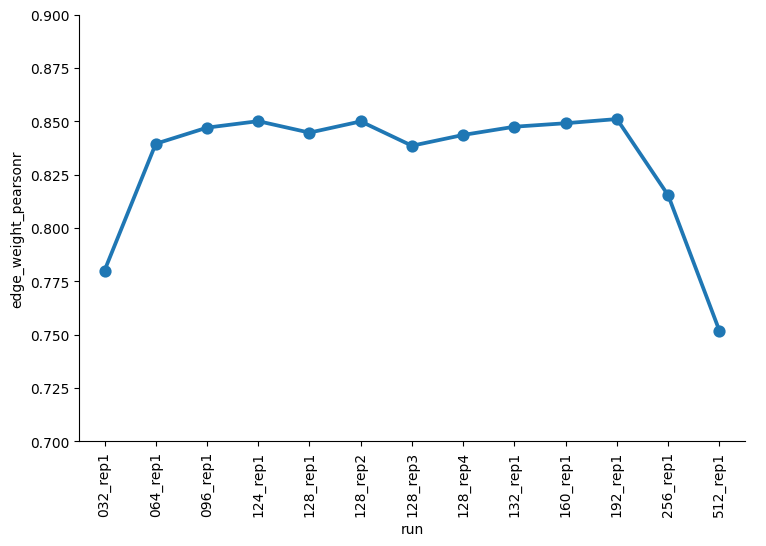

In [ ]:
sns.catplot(
    data=edge_weight_correlation_results.sort('run'),
    kind='point',
    x='run',
    y='edge_weight_pearsonr',
    aspect=1.5,
    color=sns.color_palette()[0]
)
plt.xticks(rotation=90)
plt.ylim(0.7, 0.9)
plt.ylabel('Pearson r')
plt.title('Edge weight correlation between runs and reference')
plt.savefig(
    os.path.join(OUTPUT_DIR, 'edge_weight_correlation_across_runs.svg'),
    format='svg', dpi=300, bbox_inches='tight'
)
plt.show()

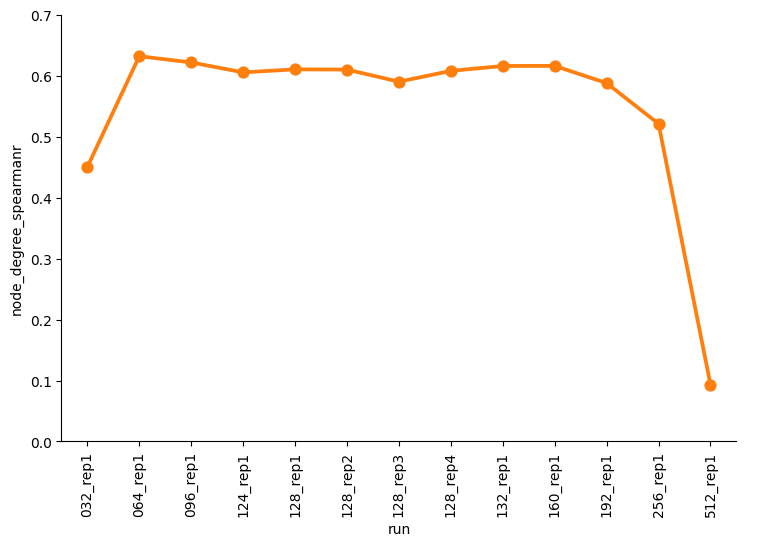

In [ ]:
sns.catplot(
    data=node_degree_correlation_results.sort('run'),
    kind='point',
    x='run',
    y='node_degree_spearmanr',
    aspect=1.5,
    color=sns.color_palette()[1]
)
plt.xticks(rotation=90)
plt.ylim(0.0, 0.7)
plt.ylabel('Spearman rho')
plt.title('Node degree correlation between runs and reference')
plt.savefig(
    os.path.join(OUTPUT_DIR, 'node_degree_correlation_across_runs.svg'),
    format='svg', dpi=300, bbox_inches='tight'
)
plt.show()

--------